## NIRS scan of 12 raster positions

This notebook shows how to connect and drive an enderscope stage.
Connect and retrieve NIRS measurements from NIR-S-G1 device


In [1]:
from enderscope import SerialUtils, Stage, ScanPatterns

In [2]:
# list available serial ports
ports = SerialUtils.serial_ports()
print (ports)

['/dev/ttyUSB0', '/dev/ttyAMA10']


In [3]:
stageport = ports[0]
s = Stage(stageport, 115200)
s.home()
s.move_relative(0,0,15)

In [6]:
# create an array of positions to perform a raster scan
import numpy as np
ori=s.get_position()
origin = [ori[0],ori[1]] # coordinates of first position
steps = [-10,-10] # x and y offsets to next item
grid = ScanPatterns.raster(4,3) * steps + origin

In [ ]:
import nir.scan_tool as st
nirs = st.connect_wait()

In [ ]:
#test 1 scan
values = st.run_scan(nirs)

In [ ]:
# do the raster scan and get data at each position

import numpy as np
scans = []

def add_scan(data):
    n = data["valid_length"]

    scan = np.column_stack((
        data["wavelength"][:n],
        data["intensity"][:n],
        data["reference"][:n],
    ))
    scans.append(scan)

for p in grid:
    s.move_position(p)
    s.finish_moves() 
    values = st.run_scan(nirs)
    scans.append(values)
# Final shape: (number_of_scans, number_of_wavelengths, 3)
spectra = np.stack(scans)
s.move_position(origin) # move back to origin

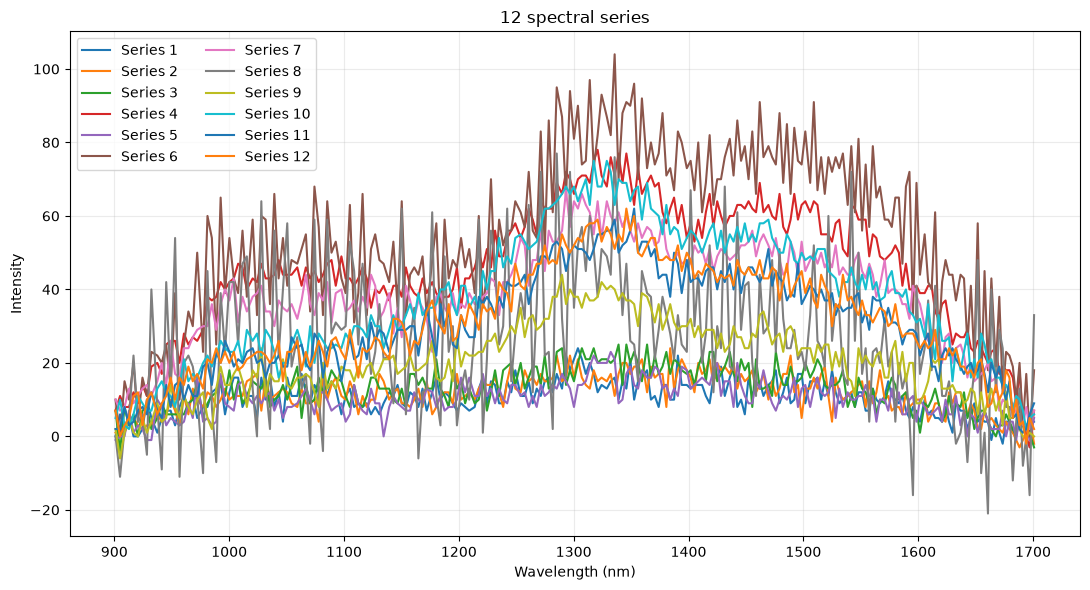

In [16]:
# plot the results

fig, ax = plt.subplots(figsize=(11, 6))

for i, scan in enumerate(spectra):
    ax.plot(
        scan["wavelength"],
        scan["intensity"],
        label=f"Series {i + 1}"
    )

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Intensity")
ax.set_title("12 spectral series")
ax.legend(ncol=2)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('output.png')